In [ ]:
from google.colab import drive

# Mount Drive to access your dataset shortcut
drive.mount('/content/drive')

# Load preprocessed data using your Drive shortcut path
DATA_PATH = "/content/drive/MyDrive/DATATHON/Train/train_cleaned.csv"
df = pd.read_csv(DATA_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import gc
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [12]:
DATA_PATH = (
    "/content/drive/MyDrive/"
    "DATATHON/Train/train_cleaned.csv"
)

SAMPLE_FRAC = 0.05
RANDOM_STATE = 42

# RAM safety
CHUNK_SIZE = 500_000

LARGE_DATA_THRESHOLD = 2_000_000

In [13]:
cols_available = pd.read_csv(
    DATA_PATH,
    nrows=0
).columns.tolist()

pickup_candidates = [
    'pickup_timestamp',
    'tpep_pickup_datetime',
    'pickup_datetime'
]

zone_candidates = [
    'origin_loc_id',
    'PULocationID',
    'pickup_zone',
    'pickup_borough'
]

weather_candidates = [
    'temp',
    'precip',
    'wind_speed',
    'visibility'
]

def first_present(candidates):
    for c in candidates:
        if c in cols_available:
            return c
    return None

pickup_col = first_present(pickup_candidates)
zone_col = first_present(zone_candidates)

if not pickup_col or not zone_col:
    raise ValueError(
        "Required columns not found. "
        "Need a pickup timestamp and a pickup zone column."
    )

weather_cols = [
    c for c in weather_candidates
    if c in cols_available
]

print("Pickup column :", pickup_col)
print("Zone column   :", zone_col)
print("Weather cols  :", weather_cols)

Pickup column : pickup_timestamp
Zone column   : origin_loc_id
Weather cols  : []


In [14]:
total_rows = 0

for row_chunk in pd.read_csv(
    DATA_PATH,
    usecols=[pickup_col],
    chunksize=1_000_000
):
    total_rows += len(row_chunk)
    del row_chunk
    gc.collect()

print(f"\nTotal rows: {total_rows:,}")


Total rows: 11,797,513


In [15]:
if total_rows > LARGE_DATA_THRESHOLD:
    print("Large dataset detected.")
    print("Using chunk-based aggregation instead of loading the full dataframe.")
else:
    print("Dataset is small enough for normal processing.")

Large dataset detected.
Using chunk-based aggregation instead of loading the full dataframe.


In [16]:
use_cols = [
    pickup_col,
    zone_col
] + weather_cols

partial_results = []

reader = pd.read_csv(
    DATA_PATH,
    usecols=use_cols,
    chunksize=CHUNK_SIZE
)

processed_rows = 0
chunk_no = 0

for chunk in reader:
    chunk_no += 1
    processed_rows += len(chunk)

    chunk[pickup_col] = pd.to_datetime(
        chunk[pickup_col],
        errors='coerce'
    )
    # Drop invalid rows
    chunk = chunk.dropna(
        subset=[
            pickup_col,
            zone_col
        ]
    )
    # Create hourly bucket
    chunk['hour'] = (
        chunk[pickup_col]
        .dt.floor('h')
    )

    agg_dict = {
        'pickup_count': (
            zone_col,
            'count'
        )
    }

    for c in weather_cols:
        agg_dict[c] = (
            c,
            'median'
        )

    chunk_agg = (
        chunk
        .groupby(
            [
                zone_col,
                'hour'
            ]
        )
        .agg(
            **agg_dict
        )
        .reset_index()
    )

    partial_results.append(chunk_agg)

    print(
        f"Chunk {chunk_no} | "
        f"Processed: {processed_rows:,}"
    )

    del chunk
    del chunk_agg
    gc.collect()

Chunk 1 | Processed: 500,000
Chunk 2 | Processed: 1,000,000
Chunk 3 | Processed: 1,500,000
Chunk 4 | Processed: 2,000,000
Chunk 5 | Processed: 2,500,000
Chunk 6 | Processed: 3,000,000
Chunk 7 | Processed: 3,500,000
Chunk 8 | Processed: 4,000,000
Chunk 9 | Processed: 4,500,000
Chunk 10 | Processed: 5,000,000
Chunk 11 | Processed: 5,500,000
Chunk 12 | Processed: 6,000,000
Chunk 13 | Processed: 6,500,000
Chunk 14 | Processed: 7,000,000
Chunk 15 | Processed: 7,500,000
Chunk 16 | Processed: 8,000,000
Chunk 17 | Processed: 8,500,000
Chunk 18 | Processed: 9,000,000
Chunk 19 | Processed: 9,500,000
Chunk 20 | Processed: 10,000,000
Chunk 21 | Processed: 10,500,000
Chunk 22 | Processed: 11,000,000
Chunk 23 | Processed: 11,500,000
Chunk 24 | Processed: 11,797,513


In [17]:
agg_df_pd = pd.concat(
    partial_results,
    ignore_index=True
)

del partial_results
gc.collect()

# Same zone/hour can appear in multiple chunks
final_agg = {
    'pickup_count': 'sum'
}

for c in weather_cols:
    final_agg[c] = 'median'

agg_df_pd = (
    agg_df_pd
    .groupby(
        [
            zone_col,
            'hour'
        ]
    )
    .agg(
        final_agg
    )
    .reset_index()
)

agg_df_pd = (
    agg_df_pd
    .sort_values(
        [
            zone_col,
            'hour'
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    f"\n✅ Aggregated demand table: "
    f"{agg_df_pd.shape[0]:,} rows × "
    f"{agg_df_pd.shape[1]} cols"
)

display(agg_df_pd.head())


✅ Aggregated demand table: 353,963 rows × 3 cols


,origin_loc_id,hour,pickup_count
0,1,2025-04-01 02:00:00,1
1,1,2025-04-01 16:00:00,1
2,1,2025-04-03 13:00:00,1
3,1,2025-04-03 18:00:00,2
4,1,2025-04-03 19:00:00,1


### Feature Engineering

This section extracts time-based features like hour of the day, day of the week, and a flag for weekends from the `hour` column.

In [18]:
agg_df_pd['hour'] = pd.to_datetime(
    agg_df_pd['hour'],
    errors='coerce'
)

agg_df_pd['hour_of_day'] = agg_df_pd['hour'].dt.hour
agg_df_pd['day_of_week'] = agg_df_pd['hour'].dt.dayofweek
agg_df_pd['is_weekend'] = agg_df_pd['day_of_week'].isin([5, 6]).astype(int)

### Encode Zone if Non-Numeric

This step ensures that the `zone_col` (origin location ID) is treated as a numeric category by encoding it if it's not already numeric.

In [19]:
if not pd.api.types.is_numeric_dtype(agg_df_pd[zone_col]):
    agg_df_pd[zone_col] = agg_df_pd[zone_col].astype('category').cat.codes

### Prepare Features and Target (X, y)

Here, we define the features and the target variable for the model, handle any missing values by filling them with the median, and convert data types to `float32` for memory efficiency.

In [20]:
feature_cols = [
    c for c in [
        'temp',
        'precip',
        'wind_speed',
        'visibility',
        'hour_of_day',
        'day_of_week',
        'is_weekend',
        zone_col
    ]
    if c in agg_df_pd.columns
]

target_col = 'pickup_count'

X_d = agg_df_pd[feature_cols].copy()
X_d = X_d.fillna(X_d.median(numeric_only=True))
X_d = X_d.astype('float32')

y_d = agg_df_pd[target_col].astype('float32')

print("\nFeatures used:", feature_cols)


Features used: ['hour_of_day', 'day_of_week', 'is_weekend', 'origin_loc_id']


### Train / Test Split

The data is split into training and testing sets to evaluate the model's performance on unseen data. Memory is managed by deleting intermediate DataFrames.

In [21]:
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_d,
    y_d,
    test_size=0.20,
    random_state=42
)

del X_d
del y_d
gc.collect()

print(f"\nTrain rows: {len(Xd_train):,}")
print(f"Test rows : {len(Xd_test):,}")


Train rows: 283,170
Test rows : 70,793


### GPU Condition Check

This cell checks for the availability of a GPU to enable CUDA for XGBoost, potentially speeding up training.

In [22]:
USE_GPU = False

try:
    subprocess.check_output(['nvidia-smi'], stderr=subprocess.STDOUT)
    USE_GPU = True
except Exception:
    USE_GPU = False

if USE_GPU:
    print("\n🚀 GPU detected - XGBoost CUDA enabled")
else:
    print("\n⚠️ GPU not detected - XGBoost using CPU")


🚀 GPU detected - XGBoost CUDA enabled


### XGBoost DMatrix Creation

The training and validation datasets are converted into `xgb.DMatrix` format, which is optimized for XGBoost.

In [23]:
dtrain = xgb.DMatrix(Xd_train, label=yd_train)
dvalid = xgb.DMatrix(Xd_test, label=yd_test)

del Xd_train
gc.collect()

7

### XGBoost Parameters

Configuration parameters for the XGBoost model are defined, including objective function, evaluation metric, and tree-specific settings. GPU usage is enabled if available.

In [24]:
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'max_depth': 8,
    'eta': 0.10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

if USE_GPU:
    params['device'] = 'cuda'

### Train Model

The XGBoost model is trained using the specified parameters, with early stopping to prevent overfitting.

In [25]:
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=600,
    evals=[
        (dtrain, 'train'),
        (dvalid, 'valid')
    ],
    early_stopping_rounds=50,
    verbose_eval=50
)

[0]	train-rmse:67.67644	valid-rmse:68.55203
[50]	train-rmse:25.75637	valid-rmse:26.46328
[100]	train-rmse:21.64154	valid-rmse:22.25929
[150]	train-rmse:18.49746	valid-rmse:19.00575
[200]	train-rmse:16.83965	valid-rmse:17.28567
[250]	train-rmse:15.97010	valid-rmse:16.40724
[300]	train-rmse:15.58308	valid-rmse:16.02976
[350]	train-rmse:15.11698	valid-rmse:15.58424
[400]	train-rmse:14.83272	valid-rmse:15.31835
[450]	train-rmse:14.61879	valid-rmse:15.12908
[500]	train-rmse:14.51081	valid-rmse:15.04280
[550]	train-rmse:14.41547	valid-rmse:14.97886
[599]	train-rmse:14.33393	valid-rmse:14.92197


### Predict Using Best Iteration

Predictions are made on the validation set using the best model iteration, ensuring that pickup demand predictions are not negative.

In [26]:
best_iteration = getattr(bst, 'best_iteration', None)

if best_iteration is not None:
    pred = bst.predict(dvalid, iteration_range=(0, best_iteration + 1))
else:
    pred = bst.predict(dvalid)

pred = np.maximum(pred, 0)

model_name = "XGBoost GPU" if USE_GPU else "XGBoost CPU"

### Evaluate Model Metrics

Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²) metrics are calculated and displayed to assess the model's performance.

In [27]:
rmse_d = float(np.sqrt(mean_squared_error(yd_test, pred)))
mae_d = float(mean_absolute_error(yd_test, pred))
r2_d = float(r2_score(yd_test, pred))

print(f"\n📈 Demand Model [{model_name}] → "
      f"RMSE: {rmse_d:.2f} | "
      f"MAE: {mae_d:.2f} | "
      f"R²: {r2_d:.4f}")

print("Features used:", feature_cols)


📈 Demand Model [XGBoost GPU] → RMSE: 14.90 | MAE: 6.46 | R²: 0.9575
Features used: ['hour_of_day', 'day_of_week', 'is_weekend', 'origin_loc_id']


### Visualize Actual vs. Predicted Values

A scatter plot is generated to visually compare the actual hourly pickups against the predicted hourly pickups for a sample of the test data.

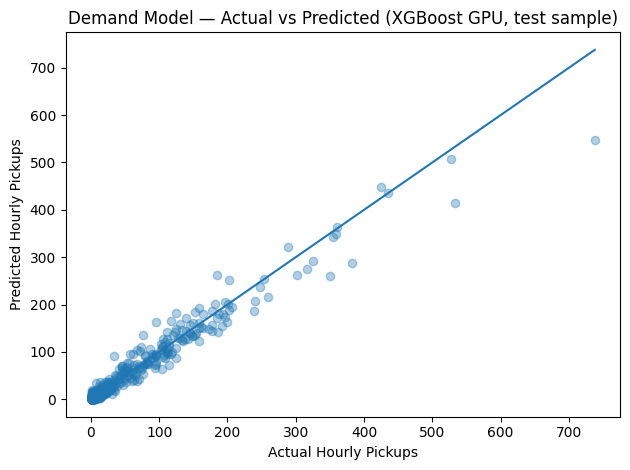

In [28]:
plt.figure()

rng = np.random.RandomState(42)
idx = rng.choice(len(yd_test), size=min(800, len(yd_test)), replace=False)

plt.scatter(yd_test.iloc[idx], np.array(pred)[idx], alpha=0.35)

lims = [
    min(yd_test.iloc[idx].min(), np.array(pred)[idx].min()),
    max(yd_test.iloc[idx].max(), np.array(pred)[idx].max())
]

plt.plot(lims, lims)
plt.xlabel("Actual Hourly Pickups")
plt.ylabel("Predicted Hourly Pickups")
plt.title(f"Demand Model — Actual vs Predicted ({model_name}, test sample)")
plt.tight_layout()
plt.show()

### Save Aggregated Table

The aggregated demand table (`agg_df_pd`) is saved to a CSV file for potential further analysis or visualization in tools like Tableau or Power BI.

In [30]:
import os

# Folder where the CSV should be saved
output_folder = "/content/drive/MyDrive/DATATHON/Hourly_DEMAND"

# Check whether folder exists
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"📁 Folder created: {output_folder}")
else:
    print(f"📁 Folder already exists: {output_folder}")

# File path inside that folder
out_path = os.path.join(
    output_folder,
    "hourly_demand_data_sampled.csv"
)

# Save CSV
# If file already exists -> overwrite/update it
# If file does not exist -> create it
agg_df_pd.to_csv(
    out_path,
    index=False
)

print(f"💾 Saved: {out_path} (ready for Tableau/Power BI)")

📁 Folder created: /content/drive/MyDrive/DATATHON/Hourly_DEMAND
💾 Saved: /content/drive/MyDrive/DATATHON/Hourly_DEMAND/hourly_demand_data_sampled.csv (ready for Tableau/Power BI)


### Save XGBoost Model

The trained XGBoost model is saved to a JSON file for later use, such as for deployment or future predictions.

In [31]:
import os
import pickle


# Folder where the model should be saved
model_folder = "/content/drive/MyDrive/Urban_flow_Analyzis/models"

# Create MODEL folder if it doesn't exist
if not os.path.exists(model_folder):

    os.makedirs(model_folder)

    print(f"📁 Folder created: {model_folder}")

else:

    print(f"📁 Folder already exists: {model_folder}")


# Model file path
model_path = os.path.join(
    model_folder,
    "xgboost_demand_model.pkl"
)


# Save trained XGBoost model
# If file exists -> overwrite it
# If file doesn't exist -> create it
with open(model_path, "wb") as file:

    pickle.dump(
        bst,
        file
    )


print(f"💾 Model saved: {model_path}")

📁 Folder created: /content/drive/MyDrive/Urban_flow_Analyzis/models
💾 Model saved: /content/drive/MyDrive/Urban_flow_Analyzis/models/xgboost_demand_model.pkl
